# Clustering avec CAH (Classification Ascendante Hiérarchique) et K-Means sur le Dataset CreditDataSet

Ce notebook présente une analyse de clustering utilisant la Classification Ascendante Hiérarchique (CAH) et K-Means sur le dataset CreditDataSet.

In [1]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from kneed import KneeLocator
import warnings
warnings.filterwarnings('ignore')

## 1. Chargement et préparation des données

In [2]:
# Chargement du dataset CreditDataSet
df = pd.read_csv('CreditDataSet.csv')
print(f"Forme du dataset: {df.shape}")

# Suppression de la colonne CUST_ID
df_model = df.drop('CUST_ID', axis=1).copy()

# Gestion des valeurs manquantes dans MINIMUM_PAYMENTS
payments_mean = np.mean(df_model['PAYMENTS'])
for idx, row in df_model.iterrows():
    if pd.isna(row['MINIMUM_PAYMENTS']):
        if row['PAYMENTS'] == 0:
            df_model.loc[idx, 'MINIMUM_PAYMENTS'] = 0
        elif 0 < row['PAYMENTS'] < payments_mean:
            df_model.loc[idx, 'MINIMUM_PAYMENTS'] = row['PAYMENTS']
        else:
            df_model.loc[idx, 'MINIMUM_PAYMENTS'] = payments_mean

# Suppression des lignes avec des valeurs manquantes restantes
df_model = df_model.dropna().reset_index(drop=True)
print(f"Forme après nettoyage: {df_model.shape}")

# Normalisation des données
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_model), 
    columns=df_model.columns
)
print("Données normalisées avec succès!")

Forme du dataset: (8950, 18)
Forme après nettoyage: (8949, 17)
Données normalisées avec succès!


## 2. Classification Ascendante Hiérarchique (CAH)

### 2.1 Présentation de la CAH

La **Classification Ascendante Hiérarchique (CAH)** est une méthode de clustering qui regroupe des individus en fonction de leurs similarités ou dissimilarités. 

Cette méthode est dite **"ascendante"** car elle construit une hiérarchie de regroupements à partir de la fusion successive des individus ou des groupes les plus similaires.

**Étapes principales:**
1. Calculer la matrice de distance entre tous les individus
2. Fusionner les deux individus/clusters les plus proches
3. Mettre à jour la matrice de distance
4. Répéter jusqu'à obtenir un seul cluster
5. Visualiser avec un dendrogramme

In [3]:
# Calcul de la matrice de linkage avec la méthode de Ward
# Ward minimise la variance intra-cluster (somme des carrés des écarts)
linkage_matrix = linkage(df_scaled, method='ward', metric='euclidean')
print("Matrice de linkage calculée avec succès!")
print(f"Forme de la matrice de linkage: {linkage_matrix.shape}")

Matrice de linkage calculée avec succès!
Forme de la matrice de linkage: (8948, 4)


### 2.2 Visualisation du dendrogramme

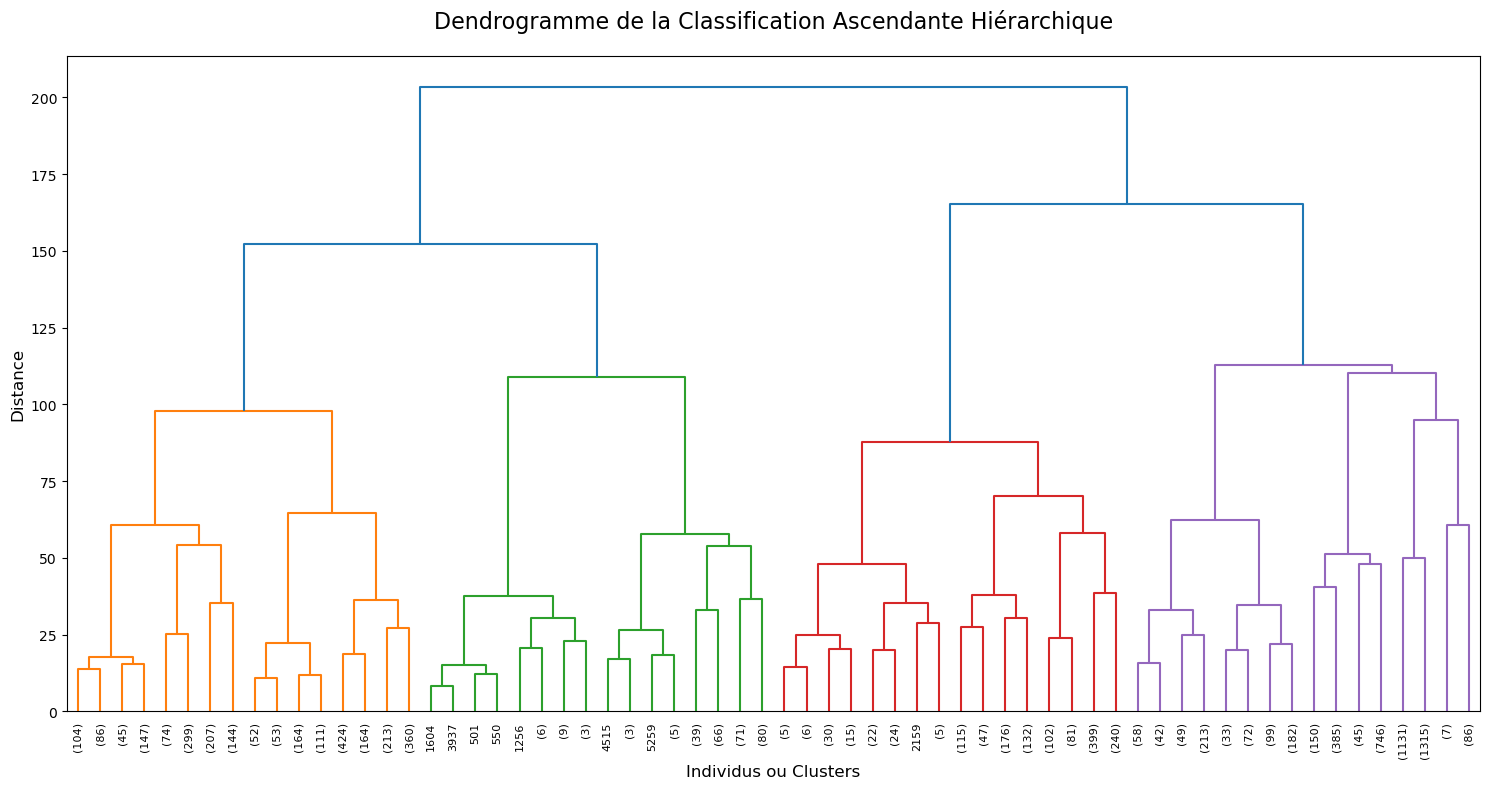

In [4]:
# Affichage du dendrogramme complet
plt.figure(figsize=(15, 8))
dendrogram(linkage_matrix, 
           truncate_mode='level', 
           p=5,  # Afficher seulement les 5 derniers niveaux pour la lisibilité
           leaf_rotation=90,
           leaf_font_size=8)
plt.title('Dendrogramme de la Classification Ascendante Hiérarchique', fontsize=16, pad=20)
plt.xlabel('Individus ou Clusters', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.tight_layout()
plt.show()

### 2.3 Détermination du nombre optimal de clusters avec la CAH

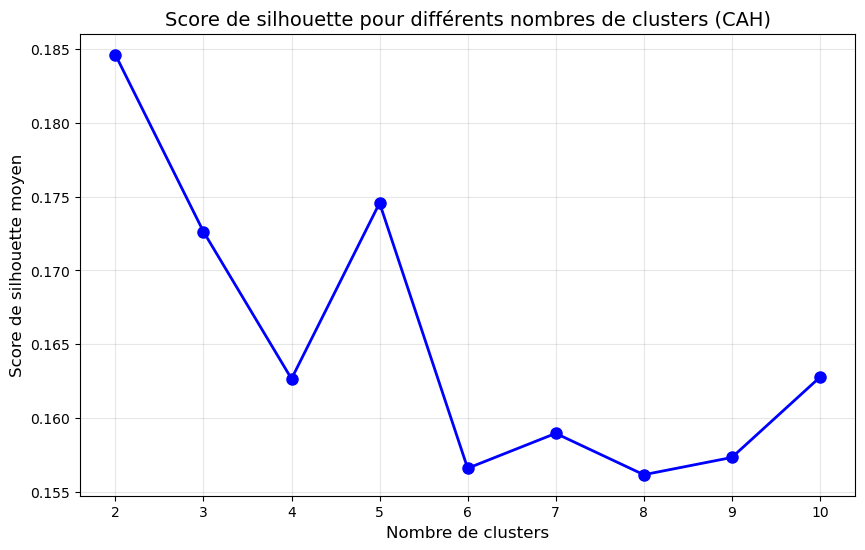

Nombre optimal de clusters selon le score de silhouette: 2
Score de silhouette optimal: 0.1846


In [5]:
# Calcul du score de silhouette pour différents nombres de clusters
max_clusters = 10
silhouette_scores_cah = []

for num_clusters in range(2, max_clusters + 1):
    clusters_cah = fcluster(linkage_matrix, num_clusters, criterion='maxclust')
    silhouette_avg = silhouette_score(df_scaled, clusters_cah)
    silhouette_scores_cah.append(silhouette_avg)

# Visualisation du score de silhouette
plt.figure(figsize=(10, 6))
plt.plot(range(2, max_clusters + 1), silhouette_scores_cah, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Nombre de clusters', fontsize=12)
plt.ylabel('Score de silhouette moyen', fontsize=12)
plt.title('Score de silhouette pour différents nombres de clusters (CAH)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

# Trouver le nombre optimal de clusters
optimal_num_clusters_cah = np.argmax(silhouette_scores_cah) + 2
print(f"Nombre optimal de clusters selon le score de silhouette: {optimal_num_clusters_cah}")
print(f"Score de silhouette optimal: {max(silhouette_scores_cah):.4f}")

In [15]:
# Application de la CAH avec le nombre optimal de clusters
num_clusters_cah = 3  # Vous pouvez ajuster selon vos besoins

clusters_cah = fcluster(linkage_matrix, num_clusters_cah, criterion='maxclust')

# Ajouter les labels de cluster au DataFrame
df_model['cluster_cah'] = clusters_cah

# Statistiques par cluster CAH
print("Répartition des clusters CAH:")
print(df_model['cluster_cah'].value_counts().sort_index())

print("\nStatistiques descriptives par cluster CAH:")
cluster_stats_cah = df_model.groupby('cluster_cah').mean()
cluster_stats_cah

Répartition des clusters CAH:
cluster_cah
1    2936
2    1400
3    4613
Name: count, dtype: int64

Statistiques descriptives par cluster CAH:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster_cah,,,,,,,,,,,,,,,,,
1,1204.765423,0.968698,2226.178597,1305.801710,920.646570,185.324739,0.901280,0.409634,0.700872,0.030264,0.602520,32.582425,5057.599238,2190.498116,647.121557,0.293637,11.955381
2,4065.168472,0.980136,633.955236,360.104700,274.136579,3815.350669,0.360169,0.148230,0.271646,0.447065,13.095000,10.760000,6788.035714,3114.393783,1475.376019,0.032914,11.839286
3,1034.815557,0.788016,337.109380,209.047056,128.386274,623.261486,0.268424,0.087099,0.178549,0.107225,1.945372,4.536527,3439.945105,1023.233182,766.992500,0.101354,11.141990


# Analyse d'hétérogénéité des groupes

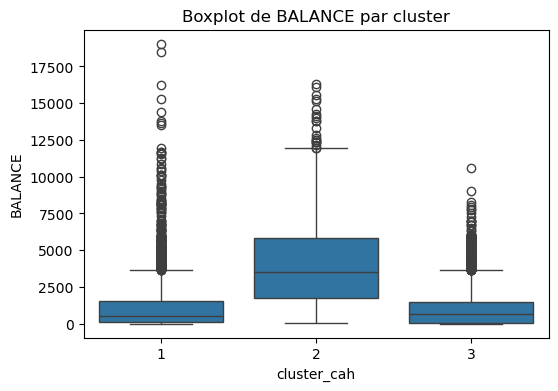

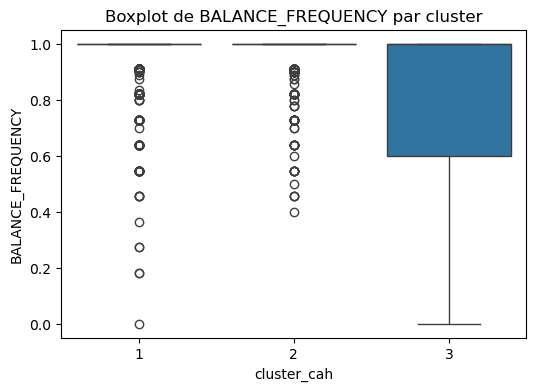

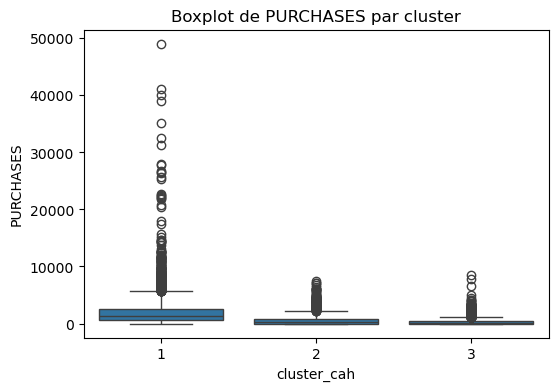

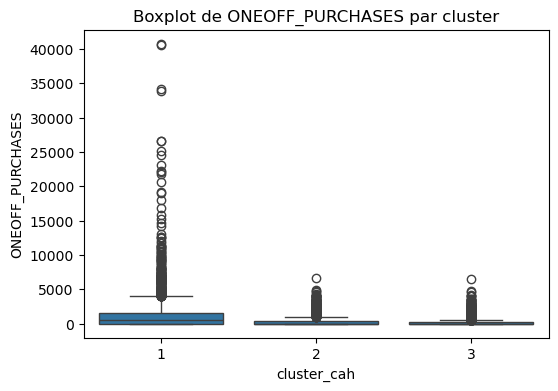

In [16]:
# Variables à analyser
variables = [
    "BALANCE",
    "BALANCE_FREQUENCY",
    "PURCHASES",
    "ONEOFF_PURCHASES"
]

for var in variables:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='cluster_cah', y=var, data=df_model)
    plt.title(f'Boxplot de {var} par cluster')
    plt.show()

In [17]:
from scipy import stats
normality_results = []

for var in variables:
    for cluster in df_model['cluster_cah'].unique():
        data = df_model[df_model['cluster_cah'] == cluster][var]
        stat, p_value = stats.shapiro(data.sample(min(len(data), 500)))  # limite si grand n
        normality_results.append([var, cluster, stat, p_value])

df_normality = pd.DataFrame(normality_results,
                            columns=["Variable", "Cluster", "Shapiro_stat", "p_value"])
df_normality

,Variable,Cluster,Shapiro_stat,p_value
0,BALANCE,3,0.816532,1.883382e-23
1,BALANCE,2,0.943555,7.397121e-13
2,BALANCE,1,0.655171,1.535503e-30
3,BALANCE_FREQUENCY,3,0.743893,4.479904e-27
4,BALANCE_FREQUENCY,2,0.341308,7.677064e-39
5,BALANCE_FREQUENCY,1,0.418860,3.744152e-37
6,PURCHASES,3,0.689111,2.619634e-29
7,PURCHASES,2,0.640198,4.710914e-31
8,PURCHASES,1,0.448798,1.880953e-36
9,ONEOFF_PURCHASES,3,0.476455,8.912569e-36


In [18]:
variance_results = []

for var in variables:
    groups = [df_model[df_model['cluster_cah'] == c][var] 
              for c in df_model['cluster_cah'].unique()]
    
    stat, p_value = stats.levene(*groups)
    
    variance_results.append([var, stat, p_value])

df_variance = pd.DataFrame(variance_results,
                           columns=["Variable", "Levene_stat", "p_value"])
df_variance

,Variable,Levene_stat,p_value
0,BALANCE,535.646674,1.903440e-220
1,BALANCE_FREQUENCY,799.775982,2.798882e-320
2,PURCHASES,478.708321,3.086821e-198
3,ONEOFF_PURCHASES,422.475457,4.746612e-176


In [19]:
from itertools import combinations
from scipy import stats

t_test_results = []

for var in variables:
    for c1, c2 in combinations(df_model['cluster_cah'].unique(), 2):
        
        group1 = df_model[df_model['cluster_cah'] == c1][var]
        group2 = df_model[df_model['cluster_cah'] == c2][var]
        
        # Test de Levene pour décider equal_var
        _, p_levene = stats.levene(group1, group2)
        equal_var = p_levene > 0.05
        
        stat, p_value = stats.ttest_ind(group1, group2, equal_var=equal_var)
        
        # Interprétation
        decision = "OK (hétérogène)" if p_value <= 0.05 else "KO (pas hétérogène)"
        
        t_test_results.append([
            var, c1, c2, stat, p_value, decision
        ])

df_ttest = pd.DataFrame(
    t_test_results,
    columns=[
        "Variable",
        "Cluster_1",
        "Cluster_2",
        "t_stat",
        "p_value",
        "Décision"
    ]
)

df_ttest

,Variable,Cluster_1,Cluster_2,t_stat,p_value,Décision
0,BALANCE,3,2,-38.871916,4.347573e-232,OK (hétérogène)
1,BALANCE,3,1,-4.413853,1.038257e-05,OK (hétérogène)
2,BALANCE,2,1,34.497947,1.735807e-204,OK (hétérogène)
3,BALANCE_FREQUENCY,3,2,-40.954801,0.000000e+00,OK (hétérogène)
4,BALANCE_FREQUENCY,3,1,-39.114756,1.107179e-297,OK (hétérogène)
5,BALANCE_FREQUENCY,2,1,4.591132,4.564247e-06,OK (hétérogène)
6,PURCHASES,3,2,-10.117851,2.215654e-23,OK (hétérogène)
7,PURCHASES,3,1,-31.074357,2.399783e-184,OK (hétérogène)
8,PURCHASES,2,1,-23.930288,2.527175e-118,OK (hétérogène)
9,ONEOFF_PURCHASES,3,2,-7.307817,4.110149e-13,OK (hétérogène)


# Analyse de l'homogénéité des groupes

In [20]:
import numpy as np
import pandas as pd
from scipy import stats

variables = [
    "BALANCE_FREQUENCY",
    "PURCHASES",
    "ONEOFF_PURCHASES"
]

results = []

for cluster in sorted(df_model["cluster_cah"].unique()):
    
    df_cluster = df_model[df_model["cluster_cah"] == cluster].copy()
    
    # Médiane intra-cluster
    median_balance = df_cluster["BALANCE"].median()
    
    # Création des sous-groupes
    df_cluster["subgroup"] = np.where(
        df_cluster["BALANCE"] > median_balance,
        "Sup_Mediane",
        "Inf_Mediane"
    )
    
    for var in variables:
        
        group1 = df_cluster[df_cluster["subgroup"] == "Sup_Mediane"][var]
        group2 = df_cluster[df_cluster["subgroup"] == "Inf_Mediane"][var]
        
        # Vérification taille minimale
        if len(group1) > 5 and len(group2) > 5:
            
            # Test de Levene
            stat_levene, p_levene = stats.levene(group1, group2)
            equal_var = p_levene > 0.05
            
            # Test de Student
            stat_t, p_value = stats.ttest_ind(group1, group2, equal_var=equal_var)
            
            decision = (
                "Hétérogène (Rejet H0)"
                if p_value <= 0.05
                else "Homogène (Non rejet H0)"
            )
            
            results.append([
                cluster,
                var,
                stat_t,
                p_value,
                p_levene,
                decision
            ])

df_intra_cluster = pd.DataFrame(
    results,
    columns=[
        "Cluster",
        "Variable",
        "t_stat",
        "p_value",
        "p_value_Levene",
        "Conclusion"
    ]
)

df_intra_cluster

,Cluster,Variable,t_stat,p_value,p_value_Levene,Conclusion
0,1,BALANCE_FREQUENCY,15.161640,5.813632e-49,4.762644e-50,Hétérogène (Rejet H0)
1,1,PURCHASES,15.697427,5.710204e-52,3.385241e-38,Hétérogène (Rejet H0)
2,1,ONEOFF_PURCHASES,14.143486,4.753384e-43,1.310457e-32,Hétérogène (Rejet H0)
3,2,BALANCE_FREQUENCY,7.109243,2.320035e-12,1.855132e-12,Hétérogène (Rejet H0)
4,2,PURCHASES,3.157262,1.629676e-03,1.146380e-03,Hétérogène (Rejet H0)
5,2,ONEOFF_PURCHASES,3.372672,7.680147e-04,7.647705e-04,Hétérogène (Rejet H0)
6,3,BALANCE_FREQUENCY,48.239221,0.000000e+00,0.000000e+00,Hétérogène (Rejet H0)
7,3,PURCHASES,-3.917286,9.084708e-05,6.325212e-01,Hétérogène (Rejet H0)
8,3,ONEOFF_PURCHASES,0.775957,4.378139e-01,4.378139e-01,Homogène (Non rejet H0)


In [ ]:
gAUC: Generalised AUC

## 3. K-Means Clustering

### 3.1 Détermination du nombre optimal de clusters avec K-Means

In [ ]:
# Méthode du coude pour K-Means
inertias = []
K_range = range(2, 11)
kmeans_settings = {"init": "random", "n_init": 10, "max_iter": 300, "random_state": 42}

for k in K_range:
    kmeans = KMeans(n_clusters=k, **kmeans_settings)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)

# Visualisation de la méthode du coude
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Nombre de clusters (k)', fontsize=12)
plt.ylabel('Inertie', fontsize=12)
plt.title('Méthode du Coude pour K-Means', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

# Trouver le point optimal avec KneeLocator
knee_locator = KneeLocator(K_range, inertias, curve='convex', direction='decreasing')
optimal_k_elbow = knee_locator.elbow
print(f"Nombre optimal de clusters (méthode du coude): {optimal_k_elbow}")

In [ ]:
# Calcul des métriques d'évaluation pour K-Means
silhouette_scores_kmeans = []
calinski_harabasz_scores = []
davies_bouldin_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, **kmeans_settings)
    kmeans.fit(df_scaled)
    labels = kmeans.labels_
    
    silhouette_scores_kmeans.append(silhouette_score(df_scaled, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(df_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(df_scaled, labels))

# Visualisation des métriques
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0, 0].axvline(x=optimal_k_elbow, color='r', linestyle='--', label=f'Optimal k={optimal_k_elbow}')
axes[0, 0].set_xlabel('Nombre de clusters')
axes[0, 0].set_ylabel('Inertie')
axes[0, 0].set_title('Méthode du Coude')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

optimal_k_silhouette = K_range[np.argmax(silhouette_scores_kmeans)]
axes[0, 1].plot(K_range, silhouette_scores_kmeans, 'go-', linewidth=2, markersize=8)
axes[0, 1].axvline(x=optimal_k_silhouette, color='r', linestyle='--', 
                   label=f'Optimal k={optimal_k_silhouette}')
axes[0, 1].set_xlabel('Nombre de clusters')
axes[0, 1].set_ylabel('Score de Silhouette')
axes[0, 1].set_title('Score de Silhouette')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

optimal_k_ch = K_range[np.argmax(calinski_harabasz_scores)]
axes[1, 0].plot(K_range, calinski_harabasz_scores, 'mo-', linewidth=2, markersize=8)
axes[1, 0].axvline(x=optimal_k_ch, color='r', linestyle='--', label=f'Optimal k={optimal_k_ch}')
axes[1, 0].set_xlabel('Nombre de clusters')
axes[1, 0].set_ylabel('Score de Calinski-Harabasz')
axes[1, 0].set_title('Score de Calinski-Harabasz')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

optimal_k_db = K_range[np.argmin(davies_bouldin_scores)]
axes[1, 1].plot(K_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
axes[1, 1].axvline(x=optimal_k_db, color='r', linestyle='--', label=f'Optimal k={optimal_k_db}')
axes[1, 1].set_xlabel('Nombre de clusters')
axes[1, 1].set_ylabel('Score de Davies-Bouldin')
axes[1, 1].set_title('Score de Davies-Bouldin')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Application de K-Means avec le nombre optimal de clusters
optimal_k = 3  # Vous pouvez ajuster selon vos besoins

kmeans_final = KMeans(n_clusters=optimal_k, **kmeans_settings)
kmeans_final.fit(df_scaled)

# Obtenir les labels de cluster
labels_kmeans = kmeans_final.labels_

# Ajouter les labels au DataFrame
df_model['cluster_kmeans'] = labels_kmeans

# Statistiques par cluster K-Means
print("Répartition des clusters K-Means:")
print(df_model['cluster_kmeans'].value_counts().sort_index())

print("\nStatistiques descriptives par cluster K-Means:")
cluster_stats_kmeans = df_model.groupby('cluster_kmeans').mean()
cluster_stats_kmeans

## 4. Comparaison des méthodes CAH et K-Means

In [ ]:
# Calcul des métriques d'évaluation pour les deux méthodes
silhouette_cah = silhouette_score(df_scaled, clusters_cah)
silhouette_kmeans = silhouette_score(df_scaled, labels_kmeans)

calinski_cah = calinski_harabasz_score(df_scaled, clusters_cah)
calinski_kmeans = calinski_harabasz_score(df_scaled, labels_kmeans)

davies_cah = davies_bouldin_score(df_scaled, clusters_cah)
davies_kmeans = davies_bouldin_score(df_scaled, labels_kmeans)

# Création d'un tableau comparatif
comparison_df = pd.DataFrame({
    'Méthode': ['CAH', 'K-Means'],
    'Score de Silhouette': [silhouette_cah, silhouette_kmeans],
    'Score de Calinski-Harabasz': [calinski_cah, calinski_kmeans],
    'Score de Davies-Bouldin': [davies_cah, davies_kmeans]
})

print("Comparaison des métriques d'évaluation:")
print(comparison_df.round(4))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

important_vars = ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS']
y_var = 'PURCHASES'


important_vars = [v for v in important_vars if v != y_var]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()


colors_cah = plt.cm.Set2(np.linspace(0, 1, df_model['cluster_cah'].nunique()))
cah_ids = sorted(df_model['cluster_cah'].unique())
cah_color = {cid: colors_cah[i] for i, cid in enumerate(cah_ids)}

colors_km = plt.cm.Set1(np.linspace(0, 1, df_model['cluster_kmeans'].nunique()))
km_ids = sorted(df_model['cluster_kmeans'].unique())
km_color = {cid: colors_km[i] for i, cid in enumerate(km_ids)}

for idx, var in enumerate(important_vars):
    ax = axes[idx]

    # --- CAH ---
    for cluster_id in cah_ids:
        cluster_data = df_model[df_model['cluster_cah'] == cluster_id]
        ax.scatter(
            cluster_data[var], cluster_data[y_var],
            marker='o', alpha=0.45, s=25,
            color=cah_color[cluster_id],
            label=f'CAH {cluster_id}'
        )

    # --- KMeans ---
    for cluster_id in km_ids:
        cluster_data = df_model[df_model['cluster_kmeans'] == cluster_id]
        ax.scatter(
            cluster_data[var], cluster_data[y_var],
            marker='^', alpha=0.45, s=25,
            color=km_color[cluster_id],
            edgecolors='black', linewidths=0.3,
            label=f'KMeans {cluster_id}'
        )

    ax.set_xlabel(var, fontsize=12)
    ax.set_ylabel(y_var, fontsize=12)
    ax.set_title(f'CAH vs K-means : {var} vs {y_var}', fontsize=12)
    ax.grid(True, alpha=0.3)

    
    ax.legend(fontsize=8, ncol=2, frameon=True)

#
for j in range(len(important_vars), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()
